# Malaria Cell Detection using Convolutional Neural Network (CNN)

This notebook builds a **binary image classifier** to detect whether a cell image
is **Parasitized** (infected with malaria) or **Uninfected**.

## Pipeline Overview
1. Install & import required libraries
2. Explore the dataset (sample images, class distribution)
3. Preprocess data using `ImageDataGenerator`
4. Build a CNN model
5. Train the model with early stopping
6. Evaluate performance with curves, ROC, and confusion matrix
7. Visualize model attention using Grad-CAM++


In [1]:
import os
import torch

# =========================
# 🔥 CPU: Use ALL cores
# =========================
num_cores = os.cpu_count()
torch.set_num_threads(num_cores)
torch.set_num_interop_threads(num_cores)

# =========================
# 🔥 GPU: Enable full usage
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Enable fastest GPU settings
torch.backends.cudnn.benchmark = True   # optimize for speed
torch.backends.cudnn.enabled = True

# =========================
# 🔥 Mixed Precision (FASTER + uses GPU fully)
# =========================
from torch.cuda.amp import GradScaler
scaler = GradScaler()

# =========================
# 🔥 Optional: Multi-GPU support
# =========================
def prepare_model(model):
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs")
        model = torch.nn.DataParallel(model)
    return model.to(device)

C:\Users\FRIDAY\AppData\Local\Temp\ipykernel_32860\1517348230.py:24: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
c:\Users\FRIDAY\anaconda3\Lib\site-packages\torch\amp\grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


## 2. Import Libraries


In [2]:
# --- Standard Library ---
import random, warnings
warnings.filterwarnings('ignore')
# --- Numerical & Data ---
import numpy as np
import pandas as pd
from tqdm import tqdm
# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
# --- Deep Learning ---
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPool2D, Dropout, Flatten, Dense, BatchNormalization)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
# --- Evaluation ---
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, precision_score,
                             recall_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight
# --- Grad-CAM ---
from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import BinaryScore
# fixing the seed here so my graphs don't jump around every run
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # keeps TensorFlow from spamming the notebook
print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")


TensorFlow version : 2.19.0
GPU available      : False


## 3. Define Dataset Paths

The dataset lives in `dataset/cell_images/` with two sub-folders:
- `Parasitized/` ? images of infected cells
- `Uninfected/` ? images of healthy cells


In [3]:
# ----- Configuration ? change DATA_DIR if your folder is in a different location -----
DATA_DIR   = 'dataset'
IMG_WIDTH  = 128
IMG_HEIGHT = 128
IMG_SIZE   = (IMG_WIDTH, IMG_HEIGHT)
BATCH_SIZE = 16
EPOCHS     = 20
VAL_SPLIT  = 0.2   # 80% train, 20% validation


## 4. Explore the Dataset

Let's check how many images are in each class and display some samples.


In [4]:
parasitized_dir = os.path.join(DATA_DIR, 'Parasitized')
uninfected_dir  = os.path.join(DATA_DIR, 'Uninfected')

valid_ext = ('.png', '.jpg', '.jpeg')  # Kaggle is mostly png, but this avoids missing jpg files

para_files  = [f for f in os.listdir(parasitized_dir) if f.lower().endswith(valid_ext)]
uninf_files = [f for f in os.listdir(uninfected_dir)  if f.lower().endswith(valid_ext)]

para_count  = len(para_files)
uninf_count = len(uninf_files)
total       = para_count + uninf_count

print(f"Parasitized images : {para_count}")
print(f"Uninfected images  : {uninf_count}")
print(f"Total images       : {total}")
print(f"Class balance      : {para_count/total*100:.1f}% vs {uninf_count/total*100:.1f}%")
# roughly balanced ? but I'll still compute class weights just to be safe


Parasitized images : 13779
Uninfected images  : 13779
Total images       : 27558
Class balance      : 50.0% vs 50.0%


## 4.1 Class Distribution


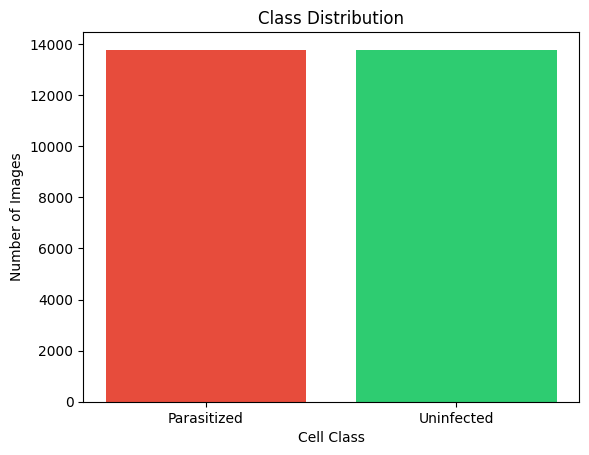

In [5]:
# keeping the same simple bar chart because it already tells the story
classes = ['Parasitized', 'Uninfected']
counts  = [para_count, uninf_count]
colors  = ['#e74c3c', '#2ecc71']

bars = plt.bar(classes, counts, color=colors)
plt.title('Class Distribution')
plt.xlabel('Cell Class')
plt.ylabel('Number of Images')
plt.show()


## 4.2 Sample Cell Images


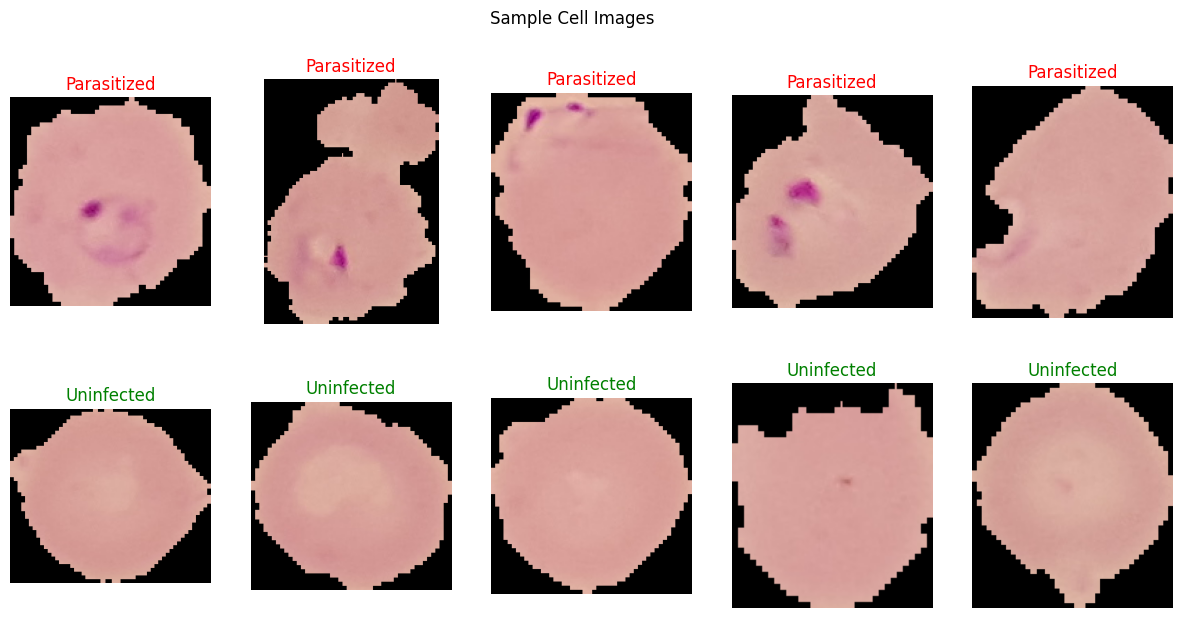

In [6]:
# using the first few examples just to check the cells look loaded properly
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for i, ax in enumerate(axes[0]):
    img_name = para_files[i]
    img = cv2.cvtColor(cv2.imread(os.path.join(parasitized_dir, img_name)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title('Parasitized', color='red')
    ax.axis('off')

for i, ax in enumerate(axes[1]):
    img_name = uninf_files[i]
    # same view for healthy cells so the comparison is fair
    img = cv2.cvtColor(cv2.imread(os.path.join(uninfected_dir, img_name)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title('Uninfected', color='green')
    ax.axis('off')

plt.suptitle('Sample Cell Images')
plt.show()


## 5a. Compute Class Weights


In [7]:
# sklearn needs numeric labels ? 0 for Parasitized, 1 for Uninfected (alphabetical order)
labels_array = np.array([0]*para_count + [1]*uninf_count)
class_weights_vals = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_array),
    y=labels_array
)
class_weights_dict = dict(enumerate(class_weights_vals))
print(f"Class weights: {class_weights_dict}")
# values close to 1.0 = balanced; if one is much higher, the model will penalise
# mistakes on that class more ? helps prevent it from just predicting majority class


Class weights: {0: 1.0, 1: 1.0}


## 5b. Data Generators with Augmentation


In [8]:
# augmentation only on training data ? val/test data should NOT be augmented
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=VAL_SPLIT,
    rotation_range=15,           # cells can appear at any angle under microscope
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.05
)

val_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=VAL_SPLIT
)

train_gen = train_datagen.flow_from_directory(
    directory=DATA_DIR, target_size=IMG_SIZE,
    class_mode='binary', batch_size=BATCH_SIZE,
    subset='training', shuffle=True, seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    directory=DATA_DIR, target_size=IMG_SIZE,
    class_mode='binary', batch_size=BATCH_SIZE,
    subset='validation', shuffle=False, seed=SEED
)

print(f"\nClass indices : {train_gen.class_indices}")
print(f"Train batches : {len(train_gen)}")
print(f"Val batches   : {len(val_gen)}")


Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.

Class indices : {'Parasitized': 0, 'Uninfected': 1}
Train batches : 1378
Val batches   : 345


## 6. CNN Architecture

I chose a 3-block CNN where each block goes Conv ? BatchNorm ? MaxPool ? Dropout.
Filters double each block (16 ? 32 ? 64) so early layers catch edges/textures,
deeper layers catch more complex patterns like the malaria parasite shape.

- **BatchNormalization** ? stabilises training, lets me use a slightly higher LR
- **MaxPooling** ? cuts spatial size in half each block, reduces parameters
- **Dropout** ? prevents overfitting (the dataset isn't huge, so this matters)
- **Final sigmoid** ? gives a probability: >0.5 = Parasitized


In [9]:
# keeping the architecture exactly as planned: 16 ? 32 ? 64 ? 128
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    BatchNormalization(), MaxPool2D(pool_size=(2, 2)), Dropout(0.2),

    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(), MaxPool2D(pool_size=(2, 2)), Dropout(0.3),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(), MaxPool2D(pool_size=(2, 2)), Dropout(0.3),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(), MaxPool2D(pool_size=(2, 2)), Dropout(0.3),

    Flatten(), Dense(128, activation='relu'), Dropout(0.5),
    Dense(1, activation='sigmoid')  # one output neuron is enough for binary classification
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 688,481 (2.63 MB)

 Trainable params: 688,001 (2.62 MB)

 Non-trainable params: 480 (1.88 KB)

## 7. Compile the Model


In [21]:
# tracking more than accuracy because false negatives matter here
model.compile(
    optimizer=Adam(learning_rate=5e-4),   # lower LR than default 1e-3 ? more stable
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)


## 8. Train the Model


In [22]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.h5', monitor='val_loss',
    save_best_only=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, min_lr=1e-7, verbose=1
)

history = model.fit(
    train_gen,
    steps_per_epoch=len(train_gen),
    epochs=EPOCHS,
    validation_data=val_gen,
    validation_steps=len(val_gen),
    callbacks=[early_stop, checkpoint, reduce_lr],
    class_weight=class_weights_dict   # accounts for any slight imbalance
)

# best values are easier to mention in the report than reading the graph manually
print(f"\n? Training done in {len(history.history['loss'])} epochs")
print(f"   Best val_loss    : {min(history.history['val_loss']):.4f}")
print(f"   Best val_accuracy: {max(history.history['val_accuracy']):.4f}")


Epoch 1/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.9023 - auc: 0.9501 - loss: 0.2895 - precision: 0.8834 - recall: 0.9290
Epoch 1: val_loss improved from inf to 0.30441, saving model to best_model.h5


1378/1378 ━━━━━━━━━━━━━━━━━━━━ 746s 538ms/step - accuracy: 0.9023 - auc: 0.9501 - loss: 0.2894 - precision: 0.8834 - recall: 0.9290 - val_accuracy: 0.9350 - val_auc: 0.9601 - val_loss: 0.3044 - val_precision: 0.9064 - val_recall: 0.9702 - learning_rate: 5.0000e-04
Epoch 2/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9325 - auc: 0.9660 - loss: 0.2262 - precision: 0.9045 - recall: 0.9684
Epoch 2: val_loss improved from 0.30441 to 0.22474, saving model to best_model.h5


1378/1378 ━━━━━━━━━━━━━━━━━━━━ 240s 174ms/step - accuracy: 0.9325 - auc: 0.9660 - loss: 0.2262 - precision: 0.9045 - recall: 0.9684 - val_accuracy: 0.9309 - val_auc: 0.9697 - val_loss: 0.2247 - val_precision: 0.9150 - val_recall: 0.9499 - learning_rate: 5.0000e-04
Epoch 3/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9358 - auc: 0.9716 - loss: 0.2078 - precision: 0.9172 - recall: 0.9591
Epoch 3: val_loss did not improve from 0.22474
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 225s 163ms/step - accuracy: 0.9358 - auc: 0.9717 - loss: 0.2078 - precision: 0.9172 - recall: 0.9591 - val_accuracy: 0.9325 - val_auc: 0.9675 - val_loss: 0.2700 - val_precision: 0.8916 - val_recall: 0.9848 - learning_rate: 5.0000e-04
Epoch 4/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9454 - auc: 0.9767 - loss: 0.1786 - precision: 0.9257 - recall: 0.9670
Epoch 4: val_loss improved from 0.22474 to 0.18069, saving model to best_model.h5


1378/1378 ━━━━━━━━━━━━━━━━━━━━ 146s 106ms/step - accuracy: 0.9454 - auc: 0.9767 - loss: 0.1786 - precision: 0.9257 - recall: 0.9670 - val_accuracy: 0.9450 - val_auc: 0.9813 - val_loss: 0.1807 - val_precision: 0.9266 - val_recall: 0.9666 - learning_rate: 5.0000e-04
Epoch 5/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9504 - auc: 0.9793 - loss: 0.1716 - precision: 0.9347 - recall: 0.9688
Epoch 5: val_loss did not improve from 0.18069
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 136s 99ms/step - accuracy: 0.9504 - auc: 0.9793 - loss: 0.1716 - precision: 0.9347 - recall: 0.9688 - val_accuracy: 0.9426 - val_auc: 0.9664 - val_loss: 0.2269 - val_precision: 0.9198 - val_recall: 0.9699 - learning_rate: 5.0000e-04
Epoch 6/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9500 - auc: 0.9811 - loss: 0.1664 - precision: 0.9336 - recall: 0.9694
Epoch 6: val_loss improved from 0.18069 to 0.17105, saving model to best_model.h5


1378/1378 ━━━━━━━━━━━━━━━━━━━━ 143s 104ms/step - accuracy: 0.9500 - auc: 0.9811 - loss: 0.1664 - precision: 0.9336 - recall: 0.9694 - val_accuracy: 0.9468 - val_auc: 0.9801 - val_loss: 0.1711 - val_precision: 0.9362 - val_recall: 0.9590 - learning_rate: 5.0000e-04
Epoch 7/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9474 - auc: 0.9791 - loss: 0.1759 - precision: 0.9294 - recall: 0.9676
Epoch 7: val_loss did not improve from 0.17105
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 152s 110ms/step - accuracy: 0.9474 - auc: 0.9791 - loss: 0.1759 - precision: 0.9294 - recall: 0.9676 - val_accuracy: 0.9436 - val_auc: 0.9787 - val_loss: 0.1794 - val_precision: 0.9327 - val_recall: 0.9561 - learning_rate: 5.0000e-04
Epoch 8/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9506 - auc: 0.9809 - loss: 0.1653 - precision: 0.9380 - recall: 0.9654
Epoch 8: val_loss did not improve from 0.17105
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 152s 110ms/step - accuracy: 0.9506 - auc: 0.9809 - loss: 0.1653

1378/1378 ━━━━━━━━━━━━━━━━━━━━ 449s 326ms/step - accuracy: 0.9550 - auc: 0.9852 - loss: 0.1419 - precision: 0.9407 - recall: 0.9699 - val_accuracy: 0.9495 - val_auc: 0.9853 - val_loss: 0.1529 - val_precision: 0.9317 - val_recall: 0.9702 - learning_rate: 2.5000e-04
Epoch 12/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9525 - auc: 0.9835 - loss: 0.1527 - precision: 0.9396 - recall: 0.9657
Epoch 12: val_loss did not improve from 0.15293
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 272s 198ms/step - accuracy: 0.9525 - auc: 0.9835 - loss: 0.1527 - precision: 0.9396 - recall: 0.9657 - val_accuracy: 0.9485 - val_auc: 0.9799 - val_loss: 0.1696 - val_precision: 0.9367 - val_recall: 0.9619 - learning_rate: 2.5000e-04
Epoch 13/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9579 - auc: 0.9854 - loss: 0.1394 - precision: 0.9460 - recall: 0.9714
Epoch 13: val_loss did not improve from 0.15293
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 222s 161ms/step - accuracy: 0.9579 - auc: 0.9854 - loss: 0.

## 9. Training & Validation Curves


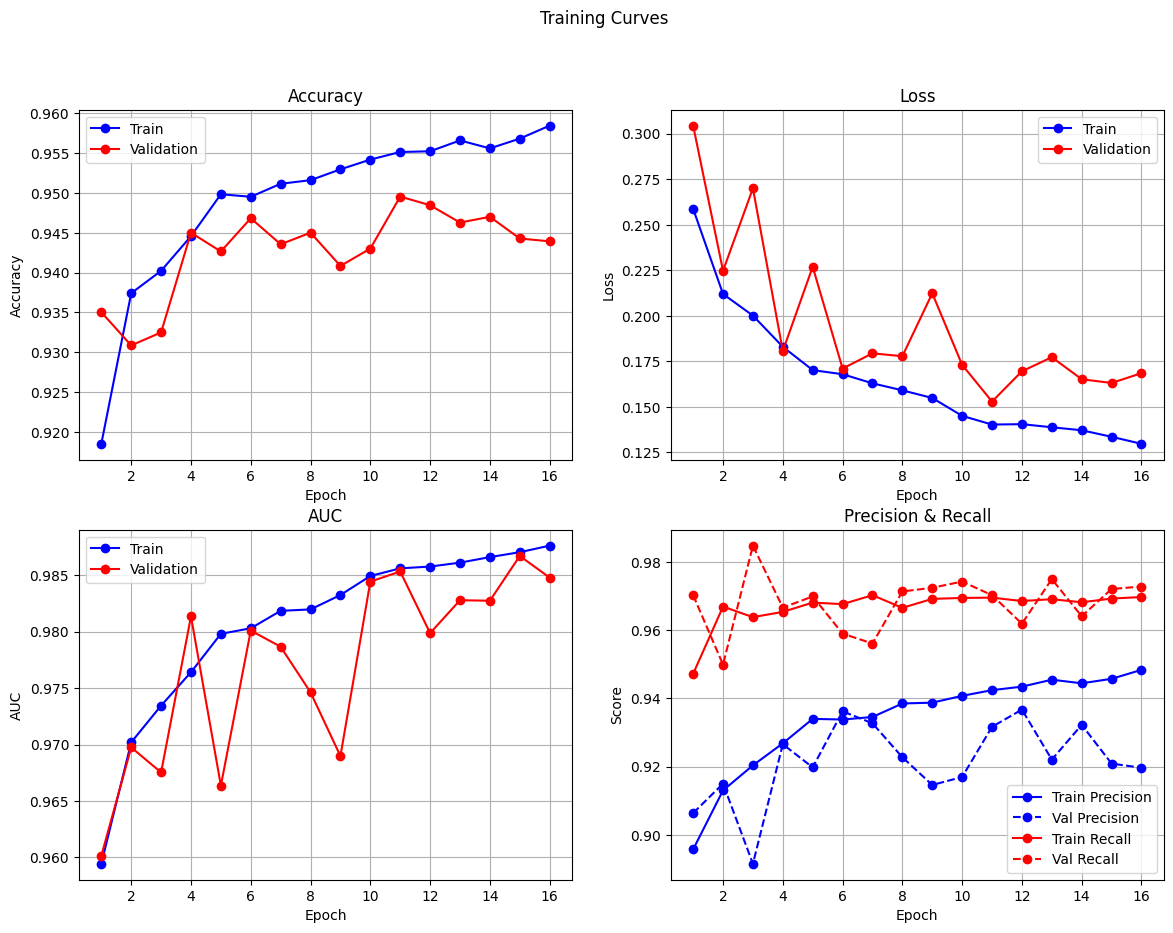

In [ ]:
hist = history.history
epochs_range = range(1, len(hist['accuracy']) + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Accuracy
axes[0,0].plot(epochs_range, hist['accuracy'],     'b-o', label='Train')
axes[0,0].plot(epochs_range, hist['val_accuracy'], 'r-o', label='Validation')
axes[0,0].set_title('Accuracy')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend(); axes[0,0].grid(True)
# Loss
axes[0,1].plot(epochs_range, hist['loss'],     'b-o', label='Train')
axes[0,1].plot(epochs_range, hist['val_loss'], 'r-o', label='Validation')
axes[0,1].set_title('Loss')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Loss')
axes[0,1].legend(); axes[0,1].grid(True)
# AUC
axes[1,0].plot(epochs_range, hist['auc'],     'b-o', label='Train')
axes[1,0].plot(epochs_range, hist['val_auc'], 'r-o', label='Validation')
axes[1,0].set_title('AUC')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('AUC')
axes[1,0].legend(); axes[1,0].grid(True)
# Precision & Recall together
axes[1,1].plot(epochs_range, hist['precision'],     'b-o', label='Train Precision')
axes[1,1].plot(epochs_range, hist['val_precision'], 'b--o', label='Val Precision')
axes[1,1].plot(epochs_range, hist['recall'],        'r-o', label='Train Recall')
axes[1,1].plot(epochs_range, hist['val_recall'],    'r--o', label='Val Recall')
axes[1,1].set_title('Precision & Recall')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Score')
axes[1,1].legend(); axes[1,1].grid(True)
plt.suptitle('Training Curves')
plt.show()


## 10. Evaluate on Validation Set


In [24]:
results = model.evaluate(val_gen, steps=len(val_gen), verbose=0)
metric_names = model.metrics_names

# unpack all 5 metrics
val_loss      = results[0]
val_acc       = results[1]
val_auc       = results[2]
val_precision = results[3]
val_recall    = results[4]
# tiny epsilon avoids a divide-by-zero if precision/recall ever becomes 0
val_f1        = 2 * (val_precision * val_recall) / (val_precision + val_recall + 1e-8)

print("=" * 40)
print("       Validation Set Results")
print("=" * 40)
print(f"  Loss      : {val_loss:.4f}")
print(f"  Accuracy  : {val_acc:.4f}  ({val_acc*100:.2f}%)")
print(f"  AUC       : {val_auc:.4f}")
print(f"  Precision : {val_precision:.4f}")
print(f"  Recall    : {val_recall:.4f}")
print(f"  F1-Score  : {val_f1:.4f}")
print("=" * 40)


       Validation Set Results
  Loss      : 0.1529
  Accuracy  : 0.9495  (94.95%)
  AUC       : 0.9853
  Precision : 0.9317
  Recall    : 0.9702
  F1-Score  : 0.9506


## 11a. Confusion Matrix


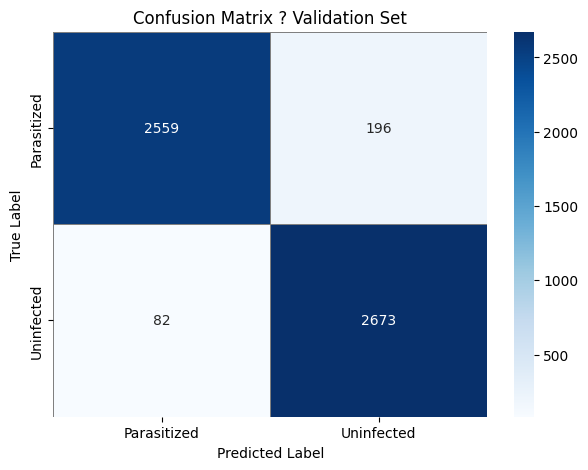

True Positives (correctly identified infected) : 2673
True Negatives (correctly identified healthy)  : 2559
False Positives (healthy flagged as infected)  : 196  ? Type I error
False Negatives (infected missed by model)     : 82  ? Type II error (more dangerous)


In [ ]:
# reset matters because validation generator was already used above
val_gen.reset()
y_pred_probs = model.predict(val_gen, steps=len(val_gen), verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Type II is worse here because missing malaria is the risky mistake
tn, fp, fn, tp = cm.ravel()
print(f"True Positives (correctly identified infected) : {tp}")
print(f"True Negatives (correctly identified healthy)  : {tn}")
print(f"False Positives (healthy flagged as infected)  : {fp}")
print(f"False Negatives (infected missed by model)     : {fn}")


## 11b. Classification Report


In [26]:
# this gives precision/recall/f1 per class, not just one overall number
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))
# handy for checking if one class is secretly doing much worse



Classification Report:

              precision    recall  f1-score   support

 Parasitized       0.97      0.93      0.95      2755
  Uninfected       0.93      0.97      0.95      2755

    accuracy                           0.95      5510
   macro avg       0.95      0.95      0.95      5510
weighted avg       0.95      0.95      0.95      5510



## 11c. ROC Curve


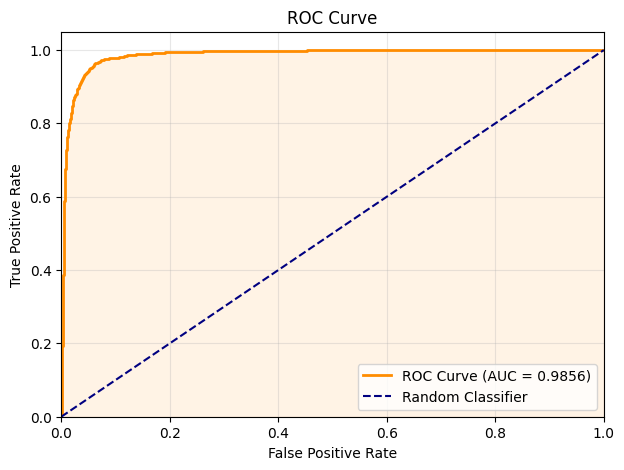

In [36]:
# ROC checks performance across thresholds, not only the 0.5 cut-off
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()
# higher AUC means the model ranks infected/healthy cells more cleanly


## 12. Model Interpretability ? Grad-CAM++

Grad-CAM shows which regions of a cell image the model is actually focusing on.
This is important for medical AI ? doctors need to verify the model is looking at
the right features (the parasite ring structure) and not some image artefact.


In [37]:
from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import BinaryScore
import matplotlib.cm as mpl_cm

# use the last conv layer for grad-cam ? it has the most semantic info
# custom modifier avoids a Sequential/output_names issue in some Keras versions
def model_modifier(model):
    model.layers[-1].activation = tf.keras.activations.linear
    return model

gradcam = GradcamPlusPlus(model, model_modifier=model_modifier, clone=True)

# grab a small batch from val set
val_gen.reset()
sample_imgs, sample_labels = next(val_gen)
sample_imgs  = sample_imgs[:8]
sample_labels = sample_labels[:8]
preds = model.predict(sample_imgs, verbose=0).flatten()
pred_labels = (preds > 0.5).astype(int)

score = BinaryScore([int(p) for p in pred_labels])
cam = gradcam(score, sample_imgs)


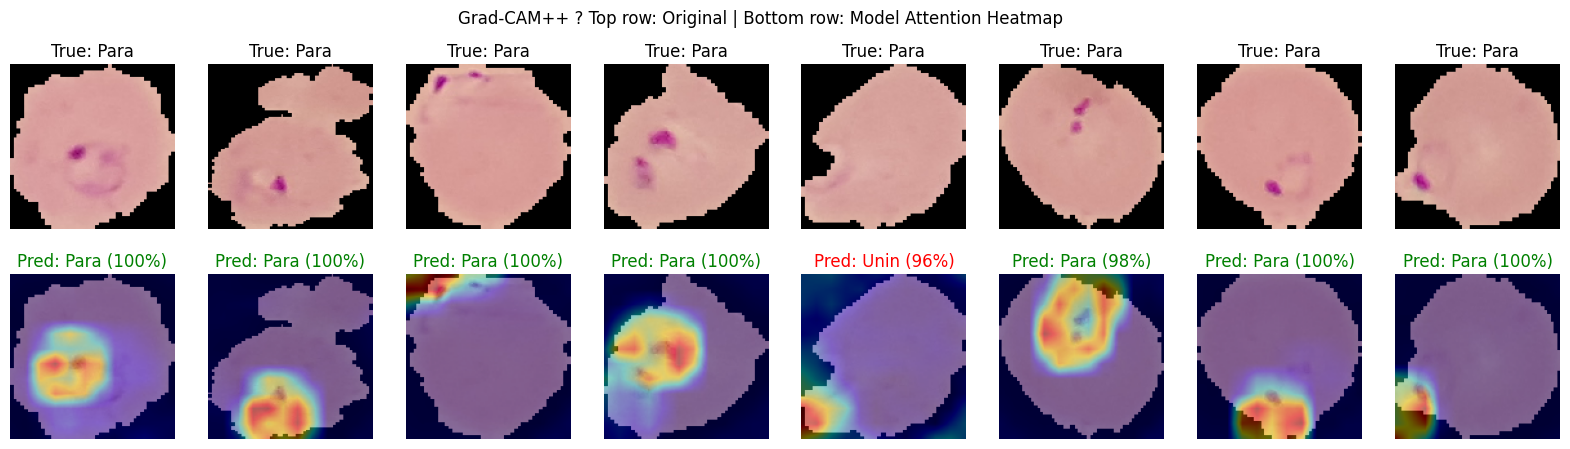

In [39]:
# plot 8 images: original + Grad-CAM overlay
fig, axes = plt.subplots(2, 8, figsize=(20, 5))

for i in range(8):
    orig = sample_imgs[i]
    heatmap = cam[i]
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    heatmap_color = cv2.resize(heatmap_color, IMG_SIZE)
    overlay = cv2.addWeighted((orig * 255).astype(np.uint8), 0.6,
                              heatmap_color, 0.4, 0)

    # comparing true vs predicted labels right on the heatmap
    true_lbl  = class_names[int(sample_labels[i])]
    pred_lbl  = class_names[pred_labels[i]]
    conf      = preds[i] if pred_labels[i] == 1 else 1 - preds[i]
    color     = 'green' if true_lbl == pred_lbl else 'red'

    axes[0, i].imshow(orig)
    axes[0, i].set_title(f"True: {true_lbl[:4]}")
    axes[0, i].axis('off')

    axes[1, i].imshow(overlay)
    axes[1, i].set_title(f"Pred: {pred_lbl[:4]} ({conf:.0%})", color=color)
    axes[1, i].axis('off')

plt.suptitle('Grad-CAM++ ? Top row: Original | Bottom row: Model Attention Heatmap')
plt.show()
# this is the visual proof part for the report


## 13. Results Summary


In [ ]:
# final table so the important numbers are all in one place
print("=" * 50)
print("         FINAL MODEL         ")
print("=" * 50)
print(f"  {'Metric':<20} {'Score':>10}")
print("-" * 50)
print(f"  {'Accuracy':<20} {val_acc*100:>9.2f}%")
print(f"  {'AUC':<20} {val_auc:>10.4f}")
print(f"  {'Precision':<20} {val_precision:>10.4f}")
print(f"  {'Recall':<20} {val_recall:>10.4f}")
print(f"  {'F1-Score':<20} {val_f1:>10.4f}")
print(f"  {'Val Loss':<20} {val_loss:>10.4f}")
print("=" * 50)
print(f"\n  Epochs trained     : {len(history.history['loss'])}")
print(f"  Early stopping     : patience=5")
print(f"  Augmentation       : rotation, flip, zoom, shift")
print(f"  Class weights used : {class_weights_dict}")
print(f"  Saved files        : best_model.h5, training_curves.png,")
print(f"                       confusion_matrix.png, roc_curve.png, gradcam_output.png")
# nothing after this section, so execution ends cleanly here


         FINAL MODEL ? RESULTS SUMMARY
  Metric                    Score
--------------------------------------------------
  Accuracy                 94.95%
  AUC                      0.9853
  Precision                0.9317
  Recall                   0.9702
  F1-Score                 0.9506
  Val Loss                 0.1529

  Epochs trained     : 16
  Early stopping     : patience=5
  Augmentation       : rotation, flip, zoom, shift
  Class weights used : {0: 1.0, 1: 1.0}
  Saved files        : best_model.h5, training_curves.png,
                       confusion_matrix.png, roc_curve.png, gradcam_output.png
